## Decision Tree Classification

### A Decision tree classifier is a machine learning algorithm that categorized the data by recursively splitting it based on feature-driven decision rules.


In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
data = load_iris()
X = data.data
y = data.target

In [4]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

In [5]:
treeclassifier = DecisionTreeClassifier(random_state=1)

In [7]:
treeclassifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
# making pred
y_pred = treeclassifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9333333333333333


In [11]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search =  GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("Best Accuracy: ", grid_search.best_score_)
print(grid_search.best_estimator_)


Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Best Accuracy:  0.9666666666666668
DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=1)


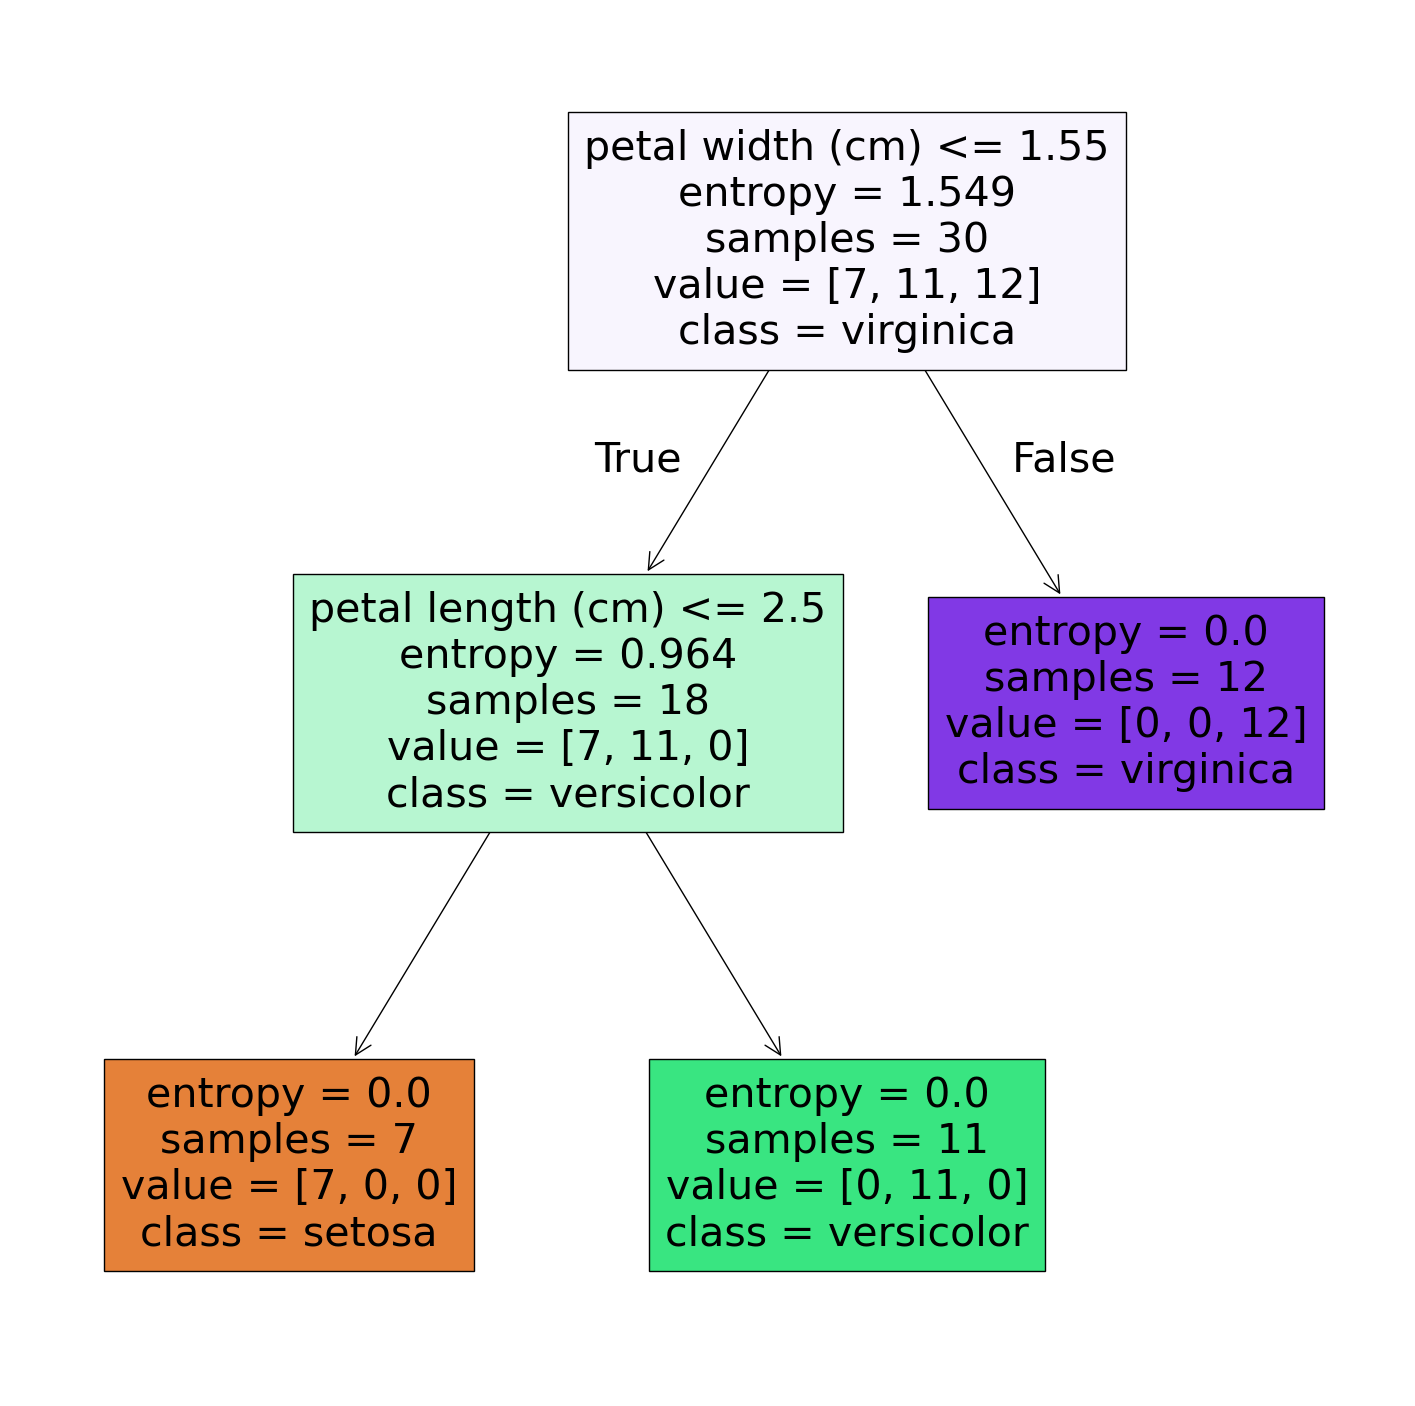

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_clf = grid_search.best_estimator_

plt.figure(figsize=(18, 18))
plot_tree(tree_clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()